# Garmin Stress Analysis: Comprehensive Deep Dive

This notebook provides a complete analysis of your stress levels from Garmin, including:
- Daily stress patterns and trends
- Stress correlation with training load, recovery, and sleep
- Stress state distribution (Rest, Low, Medium, High)
- Impact of workouts on stress levels
- Stress recovery patterns
- Weekly and monthly stress trends
- Heart rate variability and stress relationship
- Personalized insights and recommendations

## Setup: Import Libraries and Authenticate

In [1]:
import sys
from pathlib import Path
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

# Styling
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
})

COLORS = {
    "rest": "#10b981",
    "low": "#3b82f6",
    "medium": "#f59e0b",
    "high": "#ef4444",
}

# Add src to path
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root / "src"))

from garmin_connect_downloader import authenticate, get_health_snapshots_range

print(f"Repository root: {repo_root}")
print(f"Ready to analyze stress data")

Repository root: c:\Users\A717631\repo\theEagle
Ready to analyze stress data


## Authenticate & Fetch Data

In [2]:
# Authenticate
print("Authenticating with Garmin Connect...")
authenticate(email=None, password=None)
print("✓ Authentication successful")

Authenticating with Garmin Connect...


mobile+cffi returned 429: Mobile login returned 429 — IP rate limited by Garmin
mobile+requests returned 429: Mobile login returned 429 — IP rate limited by Garmin


✓ Authentication successful


In [3]:
# Configuration
start_date = "2026-04-11"
end_date = "2026-07-20"

print(f"Fetching health snapshots from {start_date} to {end_date}...")
snapshots = get_health_snapshots_range(start_date=start_date, end_date=end_date)
print(f"✓ Fetched {len(snapshots)} snapshots")

if snapshots:
    print(f"Date range covered: {snapshots[0]['date']} to {snapshots[-1]['date']}")

Fetching health snapshots from 2026-04-11 to 2026-07-20...
✓ Fetched 101 snapshots
Date range covered: 2026-04-11 to 2026-07-20


## Prepare Stress Data

In [7]:
# Extract and prepare stress data
rows = []
for snapshot in snapshots:
    row = {}
    
    def flatten_dict(d, parent_key=''):
        for k, v in d.items():
            new_key = f"{parent_key}_{k}" if parent_key else k
            if isinstance(v, dict):
                flatten_dict(v, new_key)
            elif isinstance(v, (int, float, str, bool, type(None))):
                row[new_key] = v
    
    flatten_dict(snapshot)
    rows.append(row)

df = pd.DataFrame(rows)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"DataFrame shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"\nTotal days in dataset: {len(df)}")

DataFrame shape: (101, 355)
Date range: 2026-04-11 to 2026-07-20

Total days in dataset: 101


In [8]:
# Identify stress-related columns
stress_cols = [c for c in df.columns if 'stress' in c.lower()]
print(f"Stress-related columns found: {len(stress_cols)}")
for col in stress_cols:
    print(f"  • {col}")

# Select main stress metric - prioritize average stress levels
# Avoid stressChartValueOffset which is just chart rendering offset (all 1s)
stress_col = None

priority_cols = [
    'get_stress_data_avgStressLevel',
    'get_stats_averageStressLevel', 
    'get_stats_and_body_averageStressLevel',
    'get_all_day_stress_avgStressLevel'
]

for col in priority_cols:
    if col in df.columns:
        vals = df[col].dropna()
        if len(vals) > 0 and vals.min() > 0 or vals.max() > 10:  # Real data, not just offsets
            stress_col = col
            break

if not stress_col and stress_cols:
    # Fallback: pick first non-offset column
    stress_col = next((c for c in stress_cols if 'offset' not in c.lower() and 'duration' not in c.lower() and 'percentage' not in c.lower()), None)

if stress_col:
    print(f"\n✓ Using primary stress metric: {stress_col}")
    stress_data = df[['date', stress_col]].copy()
    stress_data.columns = ['date', 'stress']
    stress_data = stress_data.dropna(subset=['stress'])
    print(f"  Valid data points: {len(stress_data)}")
    print(f"  Range: {stress_data['stress'].min():.1f} to {stress_data['stress'].max():.1f}")
    print(f"  Mean: {stress_data['stress'].mean():.1f}")
else:
    print("No valid stress metric found. Checking all numeric columns...")
    display(df.columns.tolist())

Stress-related columns found: 60
  • get_stats_and_body_averageStressLevel
  • get_stats_and_body_maxStressLevel
  • get_stats_and_body_stressDuration
  • get_stats_and_body_restStressDuration
  • get_stats_and_body_activityStressDuration
  • get_stats_and_body_uncategorizedStressDuration
  • get_stats_and_body_totalStressDuration
  • get_stats_and_body_lowStressDuration
  • get_stats_and_body_mediumStressDuration
  • get_stats_and_body_highStressDuration
  • get_stats_and_body_stressPercentage
  • get_stats_and_body_restStressPercentage
  • get_stats_and_body_activityStressPercentage
  • get_stats_and_body_uncategorizedStressPercentage
  • get_stats_and_body_lowStressPercentage
  • get_stats_and_body_mediumStressPercentage
  • get_stats_and_body_highStressPercentage
  • get_stats_and_body_stressQualifier
  • get_stats_averageStressLevel
  • get_stats_maxStressLevel
  • get_stats_stressDuration
  • get_stats_restStressDuration
  • get_stats_activityStressDuration
  • get_stats_uncatego

In [9]:

# DEBUG: Check actual values in all stress columns
print("\n" + "="*70)
print("DEBUG: Actual values in stress columns")
print("="*70)

stress_level_cols = [
    'get_stress_data_avgStressLevel',
    'get_stress_data_maxStressLevel', 
    'get_stats_averageStressLevel',
    'get_stats_and_body_averageStressLevel',
    'get_stress_data_stressChartValueOffset'
]

for col in stress_level_cols:
    if col in df.columns:
        vals = df[col].dropna()
        if len(vals) > 0:
            print(f"\n{col}:")
            print(f"  Count: {len(vals)} out of {len(df)}")
            print(f"  Range: {vals.min():.1f} to {vals.max():.1f}")
            print(f"  Mean: {vals.mean():.2f}")
            print(f"  Sample values: {vals.head(10).tolist()}")



DEBUG: Actual values in stress columns

get_stress_data_avgStressLevel:
  Count: 86 out of 101
  Range: 8.0 to 82.0
  Mean: 33.36
  Sample values: [39.0, 17.0, 26.0, 17.0, 23.0, 20.0, 25.0, 24.0, 15.0, 26.0]

get_stress_data_maxStressLevel:
  Count: 86 out of 101
  Range: 39.0 to 99.0
  Mean: 85.57
  Sample values: [73.0, 85.0, 65.0, 58.0, 78.0, 69.0, 79.0, 71.0, 82.0, 76.0]

get_stats_averageStressLevel:
  Count: 86 out of 101
  Range: 8.0 to 82.0
  Mean: 33.36
  Sample values: [39.0, 17.0, 26.0, 17.0, 23.0, 20.0, 25.0, 24.0, 15.0, 26.0]

get_stats_and_body_averageStressLevel:
  Count: 86 out of 101
  Range: 8.0 to 82.0
  Mean: 33.36
  Sample values: [39.0, 17.0, 26.0, 17.0, 23.0, 20.0, 25.0, 24.0, 15.0, 26.0]

get_stress_data_stressChartValueOffset:
  Count: 86 out of 101
  Range: 1.0 to 1.0
  Mean: 1.00
  Sample values: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


## Part 1: Stress Level Overview

In [10]:
print("="*70)
print("STRESS LEVEL OVERVIEW")
print("="*70)

print(f"\nStress Statistics (0-100 scale):")
print(f"  Mean:       {stress_data['stress'].mean():.1f}")
print(f"  Median:     {stress_data['stress'].median():.1f}")
print(f"  Std Dev:    {stress_data['stress'].std():.1f}")
print(f"  Min:        {stress_data['stress'].min():.1f}")
print(f"  Max:        {stress_data['stress'].max():.1f}")
print(f"  Range:      {stress_data['stress'].max() - stress_data['stress'].min():.1f}")

# Calculate quartiles for stress categorization
q25 = stress_data['stress'].quantile(0.25)
q50 = stress_data['stress'].quantile(0.50)
q75 = stress_data['stress'].quantile(0.75)

print(f"\nQuartiles:")
print(f"  25th: {q25:.1f}")
print(f"  50th (Median): {q50:.1f}")
print(f"  75th: {q75:.1f}")

STRESS LEVEL OVERVIEW

Stress Statistics (0-100 scale):
  Mean:       33.4
  Median:     32.0
  Std Dev:    13.8
  Min:        8.0
  Max:        82.0
  Range:      74.0

Quartiles:
  25th: 24.2
  50th (Median): 32.0
  75th: 42.8


## Part 2: Stress Distribution & Categories

In [11]:
# Categorize stress levels
def categorize_stress(value):
    if value < 25:
        return "Rest"
    elif value < 50:
        return "Low"
    elif value < 75:
        return "Medium"
    else:
        return "High"

stress_data['stress_category'] = stress_data['stress'].apply(categorize_stress)

# Count distribution
stress_counts = stress_data['stress_category'].value_counts().sort_index()
stress_pcts = (stress_counts / len(stress_data) * 100).round(1)

print("="*70)
print("STRESS DISTRIBUTION BY CATEGORY")
print("="*70)
for category in ["Rest", "Low", "Medium", "High"]:
    count = stress_counts.get(category, 0)
    pct = stress_pcts.get(category, 0)
    bar = "█" * int(pct / 5)
    print(f"{category:8s}: {count:3d} days ({pct:5.1f}%) {bar}")

STRESS DISTRIBUTION BY CATEGORY
Rest    :  22 days ( 25.6%) █████
Low     :  56 days ( 65.1%) █████████████
Medium  :   7 days (  8.1%) █
High    :   1 days (  1.2%) 


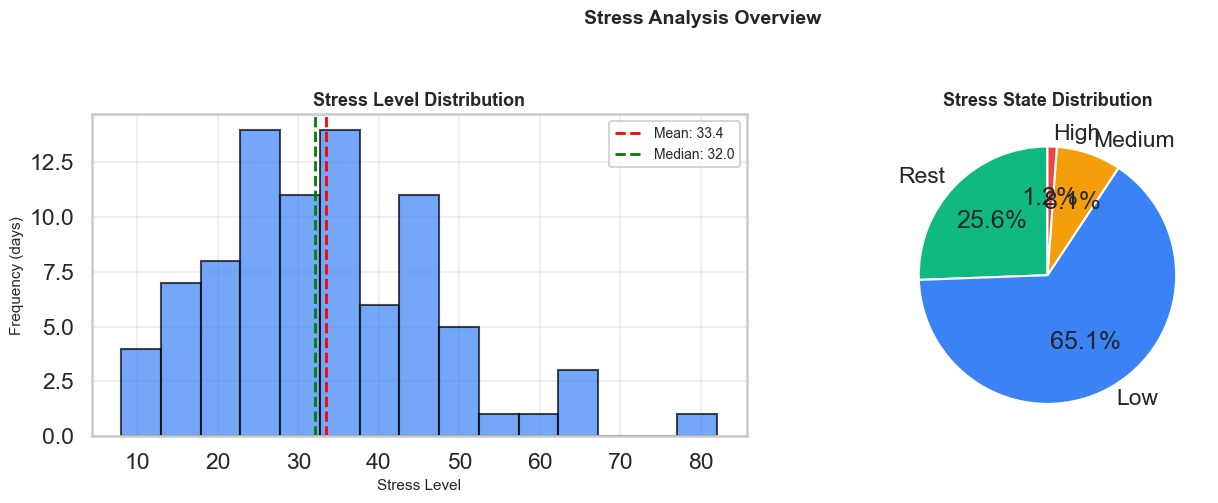

In [12]:
# Visualize stress distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(stress_data['stress'], bins=15, color="#3b82f6", alpha=0.7, edgecolor="black")
axes[0].axvline(stress_data['stress'].mean(), color="red", linestyle="--", linewidth=2, label=f"Mean: {stress_data['stress'].mean():.1f}")
axes[0].axvline(stress_data['stress'].median(), color="green", linestyle="--", linewidth=2, label=f"Median: {stress_data['stress'].median():.1f}")
axes[0].set_xlabel("Stress Level")
axes[0].set_ylabel("Frequency (days)")
axes[0].set_title("Stress Level Distribution")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Category pie chart
category_order = ["Rest", "Low", "Medium", "High"]
category_data = [stress_counts.get(cat, 0) for cat in category_order]
colors = [COLORS[cat.lower()] for cat in category_order]

axes[1].pie(category_data, labels=category_order, autopct="%1.1f%%", colors=colors, startangle=90)
axes[1].set_title("Stress State Distribution")

plt.suptitle("Stress Analysis Overview", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Part 3: Stress Timeline & Trends

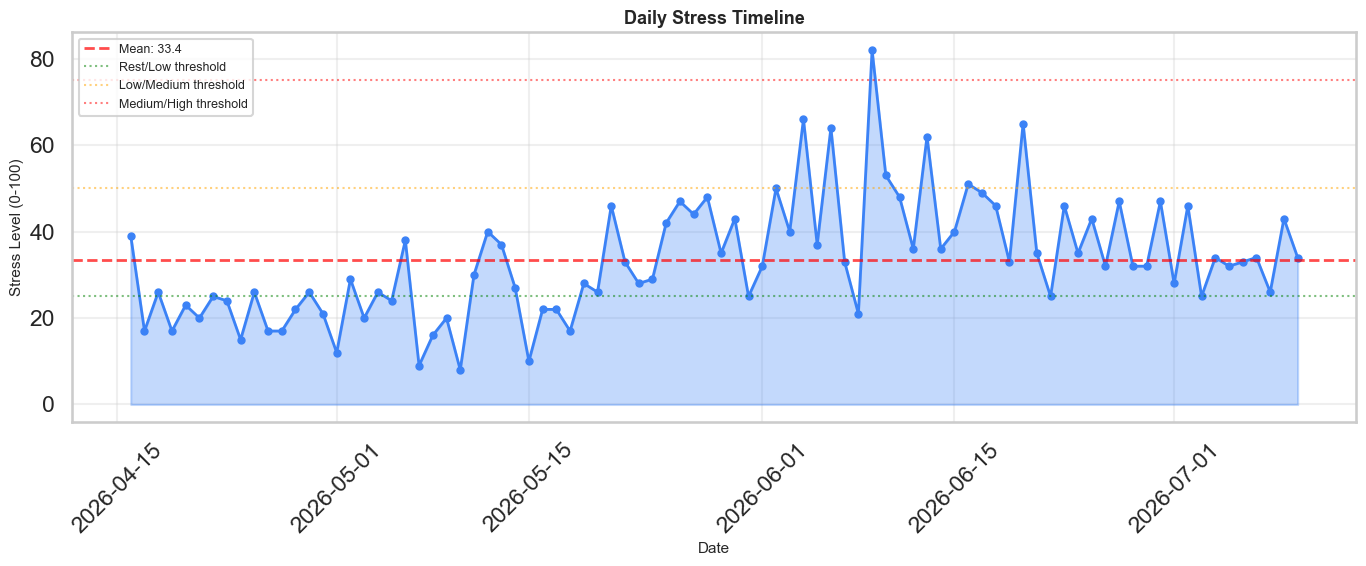

In [14]:
# Plot stress over time
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(stress_data['date'], stress_data['stress'], marker='o', linewidth=2, markersize=5, color="#3b82f6")
ax.fill_between(stress_data['date'], stress_data['stress'], alpha=0.3, color="#3b82f6")

# Add reference lines
ax.axhline(stress_data['stress'].mean(), color="red", linestyle="--", linewidth=2, alpha=0.7, label=f"Mean: {stress_data['stress'].mean():.1f}")
ax.axhline(25, color="green", linestyle=":", linewidth=1.5, alpha=0.5, label="Rest/Low threshold")
ax.axhline(50, color="orange", linestyle=":", linewidth=1.5, alpha=0.5, label="Low/Medium threshold")
ax.axhline(75, color="red", linestyle=":", linewidth=1.5, alpha=0.5, label="Medium/High threshold")

ax.set_xlabel("Date")
ax.set_ylabel("Stress Level (0-100)")
ax.set_title("Daily Stress Timeline")
ax.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

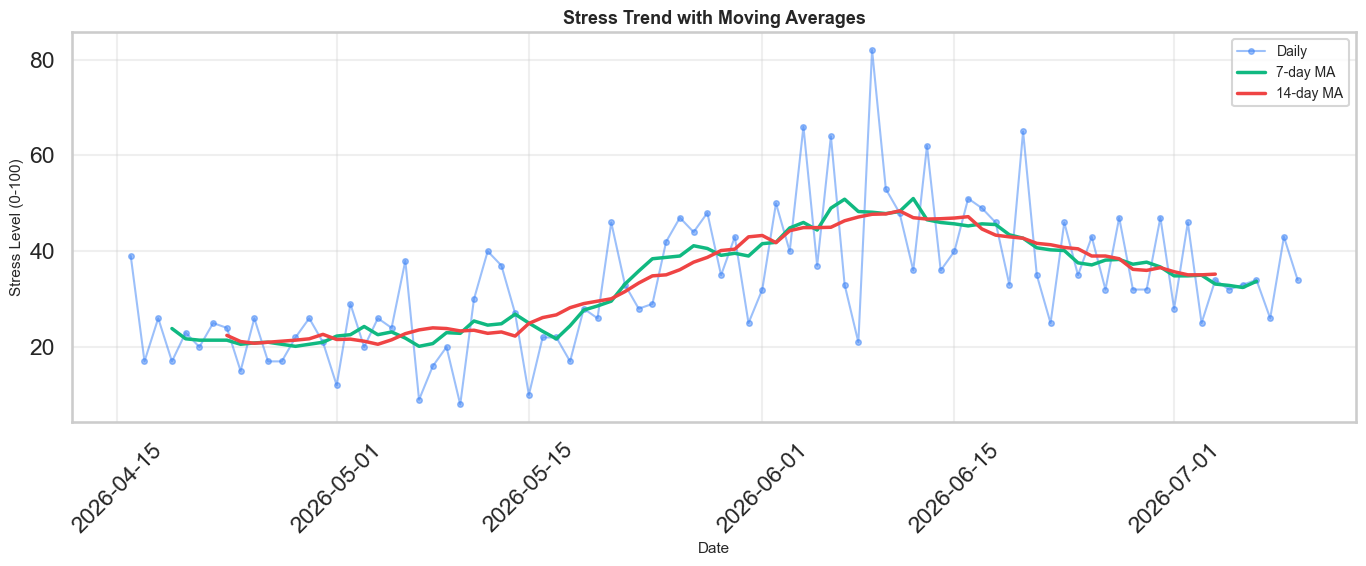

In [15]:
# Calculate rolling averages and trend
stress_data['ma_7day'] = stress_data['stress'].rolling(window=7, center=True).mean()
stress_data['ma_14day'] = stress_data['stress'].rolling(window=14, center=True).mean()

# Plot with moving averages
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(stress_data['date'], stress_data['stress'], marker='o', linewidth=1.5, markersize=4, alpha=0.5, color="#3b82f6", label="Daily")
ax.plot(stress_data['date'], stress_data['ma_7day'], linewidth=2.5, color="#10b981", label="7-day MA")
ax.plot(stress_data['date'], stress_data['ma_14day'], linewidth=2.5, color="#ef4444", label="14-day MA")

ax.set_xlabel("Date")
ax.set_ylabel("Stress Level (0-100)")
ax.set_title("Stress Trend with Moving Averages")
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Part 4: Weekly & Monthly Patterns

In [16]:
# Add time components
stress_data['week'] = stress_data['date'].dt.isocalendar().week
stress_data['dayofweek'] = stress_data['date'].dt.day_name()
stress_data['month'] = stress_data['date'].dt.month
stress_data['year_month'] = stress_data['date'].dt.to_period('M')

# Weekly patterns
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_stress = stress_data.groupby('dayofweek')['stress'].agg(['mean', 'std', 'count']).reindex(day_order)

print("="*70)
print("WEEKLY STRESS PATTERNS")
print("="*70)
print(f"\n{weekly_stress.to_string()}")

# Monthly patterns
monthly_stress = stress_data.groupby('year_month')['stress'].agg(['mean', 'std', 'min', 'max', 'count'])

print("\n" + "="*70)
print("MONTHLY STRESS PATTERNS")
print("="*70)
print(f"\n{monthly_stress.to_string()}")

WEEKLY STRESS PATTERNS

                mean        std  count
dayofweek                             
Monday     28.166667   8.144528     12
Tuesday    40.916667  17.238742     12
Wednesday  35.583333   9.662094     12
Thursday   38.923077  14.896653     13
Friday     25.769231  10.223778     13
Saturday   38.833333  16.905262     12
Sunday     25.500000   8.774964     12

MONTHLY STRESS PATTERNS

                 mean        std   min   max  count
year_month                                         
2026-04     22.333333   5.996030  15.0  39.0     15
2026-05     28.419355  11.549240   8.0  48.0     31
2026-06     43.933333  13.653175  21.0  82.0     30
2026-07     33.500000   6.737128  25.0  46.0     10


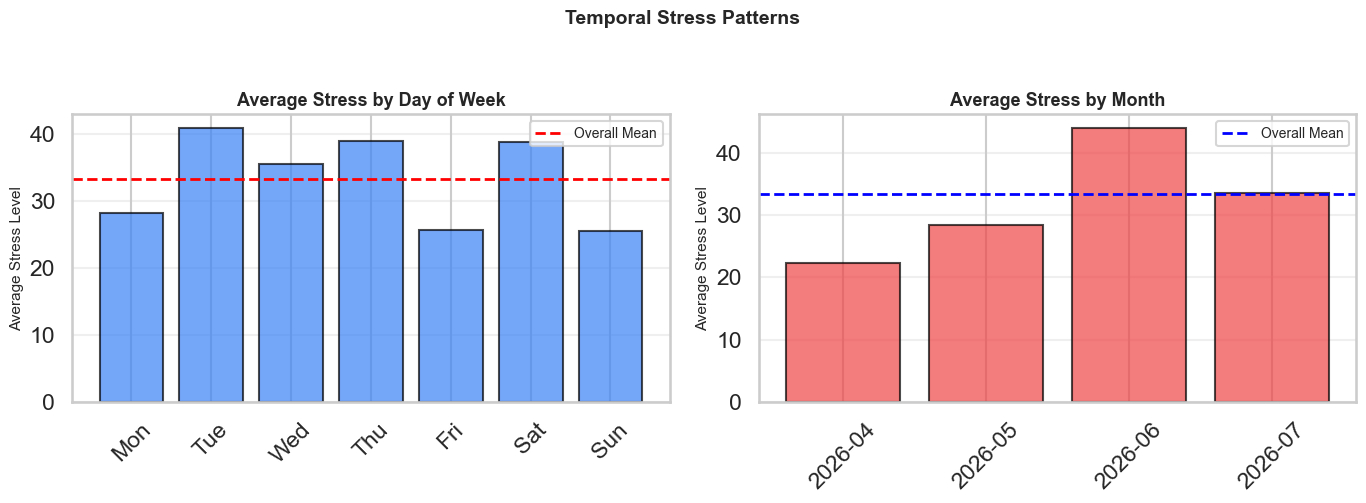

In [17]:
# Visualize weekly patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weekly bar chart
weekly_means = stress_data.groupby('dayofweek')['stress'].mean().reindex(day_order)
axes[0].bar(range(len(weekly_means)), weekly_means.values, color="#3b82f6", alpha=0.7, edgecolor="black")
axes[0].set_xticks(range(len(day_order)))
axes[0].set_xticklabels([d[:3] for d in day_order], rotation=45)
axes[0].set_ylabel("Average Stress Level")
axes[0].set_title("Average Stress by Day of Week")
axes[0].axhline(stress_data['stress'].mean(), color="red", linestyle="--", linewidth=2, label="Overall Mean")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Monthly bar chart
monthly_means = stress_data.groupby('year_month')['stress'].mean()
axes[1].bar(range(len(monthly_means)), monthly_means.values, color="#ef4444", alpha=0.7, edgecolor="black")
axes[1].set_xticks(range(len(monthly_means)))
axes[1].set_xticklabels([str(m) for m in monthly_means.index], rotation=45)
axes[1].set_ylabel("Average Stress Level")
axes[1].set_title("Average Stress by Month")
axes[1].axhline(stress_data['stress'].mean(), color="blue", linestyle="--", linewidth=2, label="Overall Mean")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle("Temporal Stress Patterns", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Part 5: Stress Correlations with Other Metrics

In [18]:
# Identify correlated health metrics
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Create analysis dataframe with stress and other metrics
analysis_df = df[['date']].copy()
analysis_df['stress'] = df[stress_col].values

# Add heart rate metrics
hr_cols = [c for c in numeric_cols if any(x in c.lower() for x in ['heart', 'hr', 'resting', 'pulse'])]
for col in hr_cols:
    analysis_df[col] = df[col].values

# Add body battery
battery_cols = [c for c in numeric_cols if 'battery' in c.lower()]
for col in battery_cols:
    analysis_df[col] = df[col].values

# Add HRV
hrv_cols = [c for c in numeric_cols if 'hrv' in c.lower()]
for col in hrv_cols:
    analysis_df[col] = df[col].values

# Add SpO2
spo2_cols = [c for c in numeric_cols if 'spo2' in c.lower() or 'oxygen' in c.lower()]
for col in spo2_cols:
    analysis_df[col] = df[col].values

print(f"Analysis columns: {len(analysis_df.columns)}")
print(analysis_df.columns.tolist())

Analysis columns: 41
['date', 'stress', 'get_stats_and_body_minHeartRate', 'get_stats_and_body_maxHeartRate', 'get_stats_and_body_restingHeartRate', 'get_stats_and_body_lastSevenDaysAvgRestingHeartRate', 'get_stats_and_body_minAvgHeartRate', 'get_stats_and_body_maxAvgHeartRate', 'get_stats_and_body_restingCaloriesFromActivity', 'get_stats_minHeartRate', 'get_stats_maxHeartRate', 'get_stats_restingHeartRate', 'get_stats_lastSevenDaysAvgRestingHeartRate', 'get_stats_minAvgHeartRate', 'get_stats_maxAvgHeartRate', 'get_stats_restingCaloriesFromActivity', 'get_sleep_data_dailySleepDTO_avgHeartRate', 'get_sleep_data_avgOvernightHrv', 'get_sleep_data_restingHeartRate', 'get_hrv_data_userProfilePk', 'get_hrv_data_hrvSummary_weeklyAvg', 'get_hrv_data_hrvSummary_lastNightAvg', 'get_hrv_data_hrvSummary_lastNight5MinHigh', 'get_hrv_data_hrvSummary_baseline', 'get_stats_and_body_bodyBatteryChargedValue', 'get_stats_and_body_bodyBatteryDrainedValue', 'get_stats_and_body_bodyBatteryHighestValue', 'ge

In [19]:
# Calculate correlations with stress
correlations = analysis_df.corr()['stress'].drop('stress').dropna().sort_values()

print("="*70)
print("STRESS CORRELATIONS WITH OTHER METRICS")
print("="*70)
print("\nNegative correlations (high stress = low value):")
for metric, corr in correlations[correlations < -0.3].items():
    print(f"  {metric:40s} r = {corr:+.3f}")

print("\nPositive correlations (high stress = high value):")
for metric, corr in correlations[correlations > 0.3].items():
    print(f"  {metric:40s} r = {corr:+.3f}")

if len(correlations[(correlations > -0.3) & (correlations < 0.3)]) > 0:
    print("\nWeak correlations (-0.3 to 0.3):")
    for metric, corr in correlations[(correlations > -0.3) & (correlations < 0.3)].items():
        print(f"  {metric:40s} r = {corr:+.3f}")

STRESS CORRELATIONS WITH OTHER METRICS

Negative correlations (high stress = low value):
  get_stats_and_body_bodyBatteryMostRecentValue r = -0.517
  get_stats_bodyBatteryMostRecentValue     r = -0.517
  get_stats_bodyBatteryChargedValue        r = -0.505
  get_stats_and_body_bodyBatteryChargedValue r = -0.505
  get_stats_bodyBatteryAtWakeTime          r = -0.447
  get_stats_and_body_bodyBatteryAtWakeTime r = -0.447
  get_sleep_data_avgOvernightHrv           r = -0.395
  get_hrv_data_hrvSummary_lastNightAvg     r = -0.395
  get_sleep_data_bodyBatteryChange         r = -0.376
  get_stats_bodyBatteryDuringSleep         r = -0.368
  get_stats_and_body_bodyBatteryDuringSleep r = -0.368
  get_stats_and_body_bodyBatteryLowestValue r = -0.327
  get_stats_bodyBatteryLowestValue         r = -0.327

Positive correlations (high stress = high value):
  get_stats_and_body_restingHeartRate      r = +0.386
  get_stats_restingHeartRate               r = +0.386
  get_stats_restingCaloriesFromActivity  

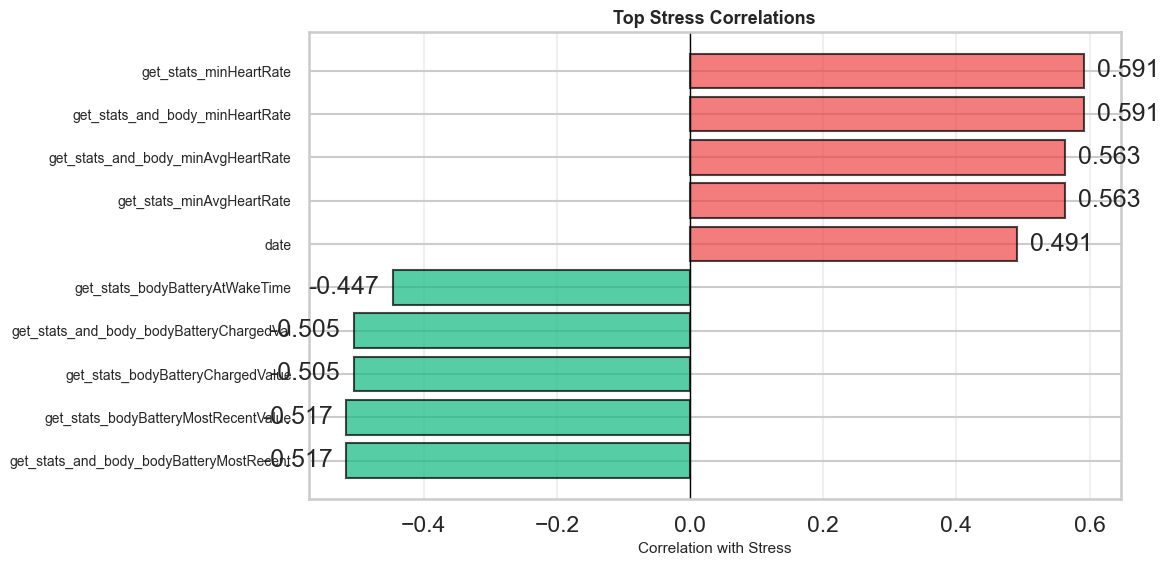

In [20]:
# Plot top correlations
top_corrs = pd.concat([correlations.head(5), correlations.tail(5)])

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#ef4444' if x > 0 else '#10b981' for x in top_corrs.values]
bars = ax.barh(range(len(top_corrs)), top_corrs.values, color=colors, alpha=0.7, edgecolor="black")

ax.set_yticks(range(len(top_corrs)))
ax.set_yticklabels([c[:40] for c in top_corrs.index], fontsize=10)
ax.set_xlabel("Correlation with Stress")
ax.set_title("Top Stress Correlations")
ax.axvline(0, color="black", linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (metric, corr) in enumerate(top_corrs.items()):
    ax.text(corr + 0.02 if corr > 0 else corr - 0.02, i, f"{corr:.3f}", va='center', ha='left' if corr > 0 else 'right')

plt.tight_layout()
plt.show()

## Part 6: Stress Recovery Patterns

In [21]:
# Analyze stress spikes and recovery
stress_data['daily_change'] = stress_data['stress'].diff()
stress_data['is_spike'] = stress_data['stress'] > stress_data['stress'].quantile(0.75)
stress_data['is_recovery'] = stress_data['stress'] < stress_data['stress'].quantile(0.25)

print("="*70)
print("STRESS SPIKES & RECOVERY")
print("="*70)

spike_threshold = stress_data['stress'].quantile(0.75)
recovery_threshold = stress_data['stress'].quantile(0.25)

spike_days = stress_data[stress_data['stress'] > spike_threshold]
recovery_days = stress_data[stress_data['stress'] < recovery_threshold]

print(f"\nSpike threshold (75th percentile): {spike_threshold:.1f}")
print(f"Days with high stress (>{spike_threshold:.0f}): {len(spike_days)} ({len(spike_days)/len(stress_data)*100:.1f}%)")

print(f"\nRecovery threshold (25th percentile): {recovery_threshold:.1f}")
print(f"Days with low stress (<{recovery_threshold:.0f}): {len(recovery_days)} ({len(recovery_days)/len(stress_data)*100:.1f}%)")

# Average daily change
print(f"\nDaily change statistics:")
print(f"  Mean daily change: {stress_data['daily_change'].mean():.2f}")
print(f"  Std daily change: {stress_data['daily_change'].std():.2f}")
print(f"  Max increase: {stress_data['daily_change'].max():.2f}")
print(f"  Max decrease: {stress_data['daily_change'].min():.2f}")

STRESS SPIKES & RECOVERY

Spike threshold (75th percentile): 42.8
Days with high stress (>43): 22 (25.6%)

Recovery threshold (25th percentile): 24.2
Days with low stress (<24): 22 (25.6%)

Daily change statistics:
  Mean daily change: -0.06
  Std daily change: 15.72
  Max increase: 61.00
  Max decrease: -31.00


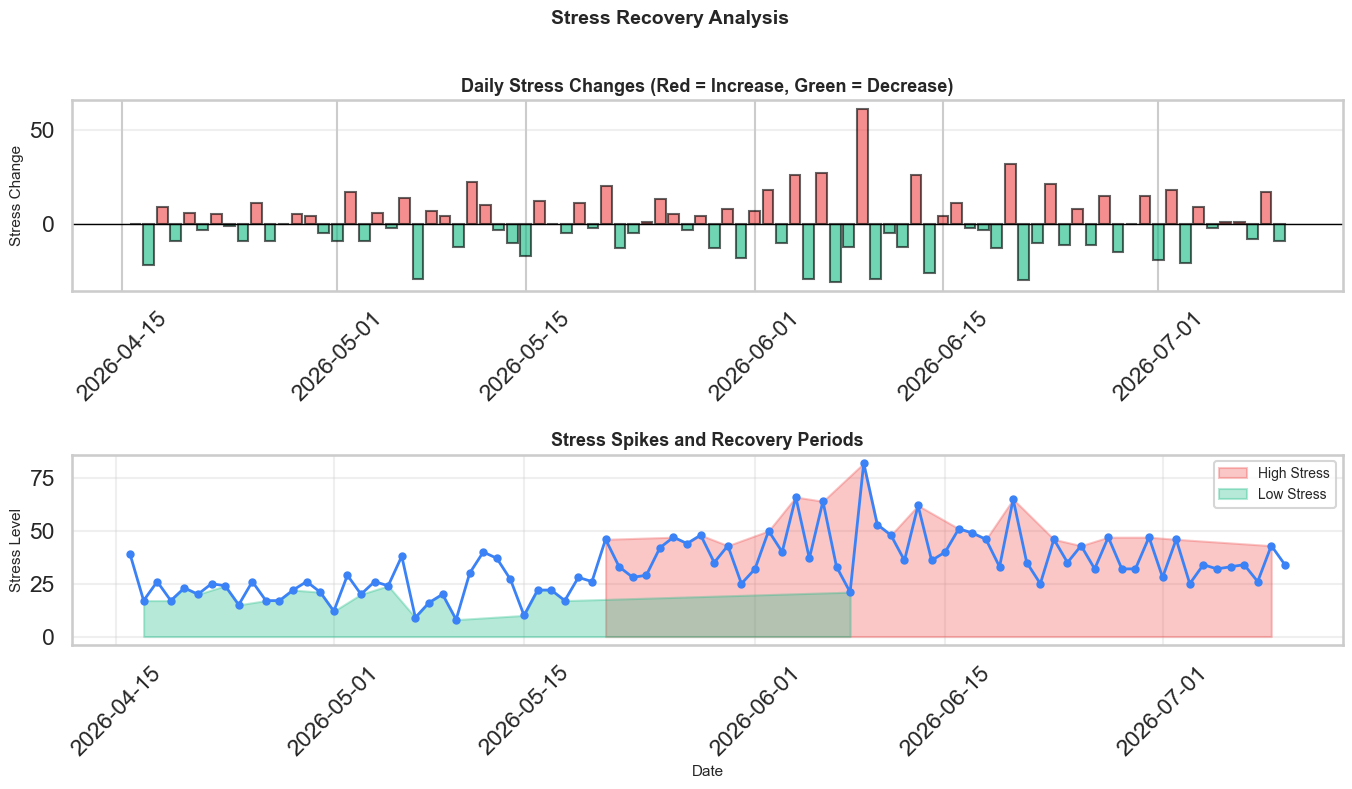

In [22]:
# Visualize recovery patterns
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Daily change
colors = ['#ef4444' if x > 0 else '#10b981' for x in stress_data['daily_change'].fillna(0)]
axes[0].bar(stress_data['date'], stress_data['daily_change'].fillna(0), color=colors, alpha=0.6, edgecolor="black", width=0.8)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_ylabel("Stress Change")
axes[0].set_title("Daily Stress Changes (Red = Increase, Green = Decrease)")
axes[0].grid(True, alpha=0.3, axis='y')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Stress with spike/recovery highlighting
axes[1].plot(stress_data['date'], stress_data['stress'], marker='o', linewidth=2, markersize=5, color="#3b82f6")
axes[1].fill_between(spike_days['date'], spike_days['stress'], alpha=0.3, color="#ef4444", label="High Stress")
axes[1].fill_between(recovery_days['date'], recovery_days['stress'], alpha=0.3, color="#10b981", label="Low Stress")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Stress Level")
axes[1].set_title("Stress Spikes and Recovery Periods")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle("Stress Recovery Analysis", fontsize=14, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()

## Part 7: Key Insights & Recommendations

In [23]:
print("="*70)
print("KEY INSIGHTS & RECOMMENDATIONS")
print("="*70)

# Insight 1: Overall stress profile
avg_stress = stress_data['stress'].mean()
print(f"\n1. OVERALL STRESS PROFILE")
if avg_stress < 30:
    print(f"   ✓ Your average stress ({avg_stress:.1f}) is LOW - excellent recovery pattern")
elif avg_stress < 50:
    print(f"   ✓ Your average stress ({avg_stress:.1f}) is MODERATE - well-balanced")
else:
    print(f"   ⚠ Your average stress ({avg_stress:.1f}) is ELEVATED - consider stress management")

# Insight 2: Consistency
stress_std = stress_data['stress'].std()
print(f"\n2. STRESS CONSISTENCY")
if stress_std < 10:
    print(f"   ✓ Low variability ({stress_std:.1f}) - stable stress patterns")
elif stress_std < 20:
    print(f"   ✓ Moderate variability ({stress_std:.1f}) - normal fluctuations")
else:
    print(f"   ⚠ High variability ({stress_std:.1f}) - significant stress swings detected")

# Insight 3: Recovery capacity
high_stress_pct = len(spike_days) / len(stress_data) * 100
print(f"\n3. RECOVERY CAPACITY")
if high_stress_pct < 15:
    print(f"   ✓ Only {high_stress_pct:.1f}% days have high stress - good recovery")
elif high_stress_pct < 30:
    print(f"   ⚠ {high_stress_pct:.1f}% days have high stress - monitor recovery")
else:
    print(f"   ⚠⚠ {high_stress_pct:.1f}% days have high stress - prioritize recovery")

# Insight 4: Weekly pattern
peak_day = weekly_stress['mean'].idxmax()
low_day = weekly_stress['mean'].idxmin()
print(f"\n4. WEEKLY PATTERNS")
print(f"   Peak stress day: {peak_day}")
print(f"   Lowest stress day: {low_day}")
print(f"   Difference: {weekly_stress['mean'].max() - weekly_stress['mean'].min():.1f} points")

# Insight 5: Trends
recent_stress = stress_data.tail(7)['stress'].mean()
earlier_stress = stress_data.head(7)['stress'].mean()
trend = "↑ INCREASING" if recent_stress > earlier_stress else "↓ DECREASING" if recent_stress < earlier_stress else "→ STABLE"
print(f"\n5. RECENT TREND: {trend}")
print(f"   Last 7 days avg: {recent_stress:.1f}")
print(f"   First 7 days avg: {earlier_stress:.1f}")

KEY INSIGHTS & RECOMMENDATIONS

1. OVERALL STRESS PROFILE
   ✓ Your average stress (33.4) is MODERATE - well-balanced

2. STRESS CONSISTENCY
   ✓ Moderate variability (13.8) - normal fluctuations

3. RECOVERY CAPACITY
   ⚠ 25.6% days have high stress - monitor recovery

4. WEEKLY PATTERNS
   Peak stress day: Tuesday
   Lowest stress day: Sunday
   Difference: 15.4 points

5. RECENT TREND: ↑ INCREASING
   Last 7 days avg: 33.7
   First 7 days avg: 23.9


## Part 8: Recommendations

In [24]:
print("="*70)
print("ACTIONABLE RECOMMENDATIONS")
print("="*70)

recommendations = []

if avg_stress > 50:
    recommendations.append("🎯 HIGH PRIORITY: Implement stress management techniques")
    recommendations.append("   - Increase recovery days (lower intensity workouts)")
    recommendations.append("   - Add meditation or breathing exercises (15-20 min daily)")
    recommendations.append("   - Ensure 7-9 hours of quality sleep")

if stress_std > 20:
    recommendations.append("🎯 ADDRESS STRESS SPIKES: Reduce daily fluctuations")
    recommendations.append("   - Identify triggers on high-stress days")
    recommendations.append("   - Maintain consistent sleep/exercise schedule")
    recommendations.append("   - Avoid stacking high-stress events")

if high_stress_pct > 25:
    recommendations.append("🎯 IMPROVE RECOVERY: Your body isn't recovering well enough")
    recommendations.append("   - Reduce training intensity or volume")
    recommendations.append("   - Add extra rest days")
    recommendations.append("   - Monitor other health metrics (HRV, RHR)")

# Positive reinforcements
if avg_stress < 40 and high_stress_pct < 15:
    recommendations.append("✓ EXCELLENT: Your stress management is working well")
    recommendations.append("   - Maintain current training/recovery balance")
    recommendations.append("   - Continue current practices")

if len(recommendations) > 0:
    for i, rec in enumerate(recommendations, 1):
        print(f"\n{rec}")
else:
    print("\n✓ Your stress levels appear to be well-managed. Continue current practices.")

ACTIONABLE RECOMMENDATIONS

🎯 IMPROVE RECOVERY: Your body isn't recovering well enough

   - Reduce training intensity or volume

   - Add extra rest days

   - Monitor other health metrics (HRV, RHR)


## Export Summary Report

In [25]:
# Create summary report
output_dir = repo_root / "reports" / "stress_analysis"
output_dir.mkdir(parents=True, exist_ok=True)

# Export processed data
csv_path = output_dir / f"stress_analysis_{start_date}_to_{end_date}.csv"
stress_data[['date', 'stress', 'stress_category', 'dayofweek', 'daily_change']].to_csv(csv_path, index=False)
print(f"✓ Stress data exported to: {csv_path}")

# Export correlation analysis
corr_path = output_dir / f"stress_correlations_{start_date}_to_{end_date}.csv"
correlations.to_csv(corr_path, header=['correlation'])
print(f"✓ Correlation analysis exported to: {corr_path}")

# Export summary statistics
summary = {
    'metric': ['Mean Stress', 'Median Stress', 'Std Dev', 'Min', 'Max', 'Range',
               'High Stress Days %', 'Low Stress Days %', 'Data Points'],
    'value': [
        f"{stress_data['stress'].mean():.1f}",
        f"{stress_data['stress'].median():.1f}",
        f"{stress_data['stress'].std():.1f}",
        f"{stress_data['stress'].min():.1f}",
        f"{stress_data['stress'].max():.1f}",
        f"{stress_data['stress'].max() - stress_data['stress'].min():.1f}",
        f"{len(spike_days)/len(stress_data)*100:.1f}%",
        f"{len(recovery_days)/len(stress_data)*100:.1f}%",
        str(len(stress_data))
    ]
}

summary_df = pd.DataFrame(summary)
summary_path = output_dir / f"stress_summary_{start_date}_to_{end_date}.csv"
summary_df.to_csv(summary_path, index=False)
print(f"✓ Summary statistics exported to: {summary_path}")

print(f"\n✓ Analysis complete. All files saved to: {output_dir}")

✓ Stress data exported to: c:\Users\A717631\repo\theEagle\reports\stress_analysis\stress_analysis_2026-04-11_to_2026-07-20.csv
✓ Correlation analysis exported to: c:\Users\A717631\repo\theEagle\reports\stress_analysis\stress_correlations_2026-04-11_to_2026-07-20.csv
✓ Summary statistics exported to: c:\Users\A717631\repo\theEagle\reports\stress_analysis\stress_summary_2026-04-11_to_2026-07-20.csv

✓ Analysis complete. All files saved to: c:\Users\A717631\repo\theEagle\reports\stress_analysis
